# Electron Density Temporal Prediction — GAT with Delta Scaling (Model-Only Eval)

**Task**: Given electron density at 10,540 grid points for **5 consecutive timesteps**, predict density at the **next timestep**.  
**Dataset**: Ammonia NH₃ — 401 timesteps (0→2000, step=5).



In [ ]:

import os, glob, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv

warnings.filterwarnings('ignore')
sns.set_style('darkgrid')
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 12,
                     'axes.titlesize': 13, 'axes.labelsize': 11})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"📦 PyTorch: {torch.__version__}")

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

🖥️  Device: cuda
   GPU: NVIDIA RTX A6000
   VRAM: 50.9 GB
📦 PyTorch: 2.2.1+cu121


## 2. Configuration

In [ ]:

DATASET_NAME  = "ammonia_x"          
DATA_DIR      = Path("../data/raw") / DATASET_NAME
LOOKBACK      = 5                    
LOOKAHEAD     = 1                    

# Model
HIDDEN_DIM    = 128
NUM_LAYERS    = 4
NUM_HEADS     = 4
DROPOUT       = 0.10
K_NEIGHBORS   = 10   # spatial kNN edges
SEQ_NEIGHBORS = 5    # sequential edges

# Training
EPOCHS        = 100
LR            = 3e-4
WEIGHT_DECAY  = 1e-4
BATCH_SIZE    = 2
PATIENCE      = 20   
GRAD_CLIP     = 1.0

ACTIVE_STD_THRESHOLD = 1e-6   
TRAIN_RATIO          = 0.80
VAL_RATIO            = 0.10
TEST_RATIO           = 0.10

MODEL_DIR   = Path("../models");  MODEL_DIR.mkdir(exist_ok=True)
REPORTS_DIR = Path("../reports"); REPORTS_DIR.mkdir(exist_ok=True)

print(f"⚙️  Config: dataset={DATASET_NAME}, lookback={LOOKBACK}, lookahead={LOOKAHEAD}")
print(f"   Model: hidden={HIDDEN_DIM}, layers={NUM_LAYERS}, heads={NUM_HEADS}")
print(f"   Training: epochs={EPOCHS}, LR={LR}, batch={BATCH_SIZE}")
print(f"   Active node threshold: {ACTIVE_STD_THRESHOLD}")

⚙️  Config: dataset=ammonia_x, lookback=5, lookahead=1
   Model: hidden=128, layers=4, heads=4
   Training: epochs=100, LR=0.0003, batch=2
   Active node threshold: 1e-06


## 3. Data Loading

Each `rvlab.tdscf.rho.XXXXX` file: 10,540 rows × 2 columns (index | density).  
We load **all 401 timesteps** at once into a matrix for efficient processing.  
**float64** precision is used throughout preprocessing to avoid numerical issues with tiny deltas.

In [ ]:

def load_density_file(fp):
    return np.loadtxt(fp)[:, 1]   

def load_grid_coords(data_dir):
    coords = []
    reading = False
    with open(data_dir / "rvlab.tdscf.xyz") as f:
        for line in f:
            if '[Grid]' in line:
                reading = True; continue
            if reading:
                p = line.strip().split()
                if len(p) == 4:
                    try: coords.append([float(p[1]), float(p[2]), float(p[3])])
                    except ValueError: pass
    return np.array(coords)

density_files = sorted(
    [f for f in glob.glob(str(DATA_DIR / "rvlab.tdscf.rho.*"))
     if not f.endswith('.xyz') and not f.endswith('.out')],
    key=lambda x: int(x.split('.')[-1])
)
timestep_ids = [int(f.split('.')[-1]) for f in density_files]

print(f"📂 {DATASET_NAME}: {len(density_files)} files, t={timestep_ids[0]}→{timestep_ids[-1]}")
print("⏳ Loading all timesteps into float64 matrix...")

all_raw = np.stack([load_density_file(f) for f in density_files], axis=0)  # (401, 10540)
all_raw = all_raw.astype(np.float64)

grid_coords = load_grid_coords(DATA_DIR)
NUM_NODES   = all_raw.shape[1]
NUM_TS      = all_raw.shape[0]

print(f"   Shape: {all_raw.shape}  —  {NUM_TS} timesteps × {NUM_NODES} nodes")
print(f"   Raw density range: [{all_raw.min():.4e}, {all_raw.max():.4f}]")

all_tf = np.log1p(np.clip(all_raw, 0, None))   # (401, 10540) float64
print(f"   log1p range:  [{all_tf.min():.4f}, {all_tf.max():.4f}]  (compressed ✅)")

📂 ammonia_x: 401 files, t=0→2000
⏳ Loading all timesteps into float64 matrix...
   Shape: (401, 10540)  —  401 timesteps × 10540 nodes
   Raw density range: [7.4166e-17, 196.6391]
   log1p range:  [0.0000, 5.2864]  (compressed ✅)


## 4. Dataset Insights & Skewness Analysis

Understanding the two core challenges:
1. **Spatial skewness** — density spans 17 orders of magnitude
2. **Temporal signal** — consecutive changes are ~0.001% of full range

We compute delta statistics from the **training portion only** (no data leakage).

In [ ]:
n_samples_total = NUM_TS - LOOKBACK - LOOKAHEAD + 1  # = 396
n_train_samples = int(TRAIN_RATIO * n_samples_total)
train_ts_end = n_train_samples + LOOKBACK          # exclusive

all_deltas = np.diff(all_tf, axis=0) 

train_deltas = all_deltas[:train_ts_end - 1]     

DELTA_MEAN = train_deltas.mean()      # scalar float64 ≈ 0
DELTA_STD  = train_deltas.std()       # scalar float64 ≈ 6.4e-5
SCALE      = 1.0 / DELTA_STD          # ≈ 15,680

per_node_std  = train_deltas.std(axis=0)   # (10540,) how much each node varies
per_node_mean = train_deltas.mean(axis=0)

active_mask = per_node_std > ACTIVE_STD_THRESHOLD  # (10540,) bool
N_ACTIVE    = active_mask.sum()
N_STATIC    = (~active_mask).sum()

print("=" * 70)
print("📊 DATA INSIGHTS")
print("=" * 70)
print(f"\n🔹 Raw Density:")
print(f"   Min:    {all_raw.min():.4e}   Max:  {all_raw.max():.4f}")
print(f"   Skew:   {stats.skew(all_raw[0]):.2f}  (highly right-skewed)")
print(f"\n🔹 log1p-Transformed:")
print(f"   Range:  [{all_tf.min():.4f}, {all_tf.max():.4f}]  (compressed ✅)")
print(f"   Skew:   {stats.skew(all_tf[0]):.2f}  (much better)")
print(f"\n🔹 Consecutive Deltas (transformed, training portion):")
print(f"   Range:  [{train_deltas.min():.6e}, {train_deltas.max():.6e}]")
print(f"   Mean:   {DELTA_MEAN:.6e}")
print(f"   Std:    {DELTA_STD:.6e}")
print(f"   → PROBLEM: sigma = {DELTA_STD:.2e}  (model output would be noise at this scale)")
print(f"\n🔹 After Standardization (÷ σ):")
print(f"   Scale factor: {SCALE:.0f}×")
scaled_demo = (train_deltas - DELTA_MEAN) / DELTA_STD
print(f"   Range: [{scaled_demo.min():.2f}, {scaled_demo.max():.2f}]  ✅ learnable range!")
print(f"   Std:   {scaled_demo.std():.4f}")
print(f"\n🔹 Node Activity (training deltas):")
print(f"   Active nodes (std > {ACTIVE_STD_THRESHOLD}): {N_ACTIVE} ({N_ACTIVE/NUM_NODES*100:.1f}%)")
print(f"   Static nodes:                         {N_STATIC} ({N_STATIC/NUM_NODES*100:.1f}%)")

d32 = train_deltas.astype(np.float32).astype(np.float64)
prec_loss = np.abs(train_deltas - d32)
print(f"\n🔹 Precision (float32 vs float64 for delta computation):")
print(f"   Mean precision loss:  {prec_loss.mean():.2e}")
print(f"   As fraction of delta: {prec_loss.mean()/np.abs(train_deltas).mean():.6f} → negligible")

📊 DATA INSIGHTS

🔹 Raw Density:
   Min:    7.4166e-17   Max:  196.6391
   Skew:   4.08  (highly right-skewed)

🔹 log1p-Transformed:
   Range:  [0.0000, 5.2864]  (compressed ✅)
   Skew:   3.34  (much better)

🔹 Consecutive Deltas (transformed, training portion):
   Range:  [-4.738170e-04, 4.745007e-04]
   Mean:   -5.692293e-11
   Std:    6.339347e-05
   → PROBLEM: sigma = 6.34e-05  (model output would be noise at this scale)

🔹 After Standardization (÷ σ):
   Scale factor: 15774×
   Range: [-7.47, 7.49]  ✅ learnable range!
   Std:   1.0000

🔹 Node Activity (training deltas):
   Active nodes (std > 1e-06): 6411 (60.8%)
   Static nodes:                         4129 (39.2%)

🔹 Precision (float32 vs float64 for delta computation):
   Mean precision loss:  6.59e-13
   As fraction of delta: 0.000000 → negligible


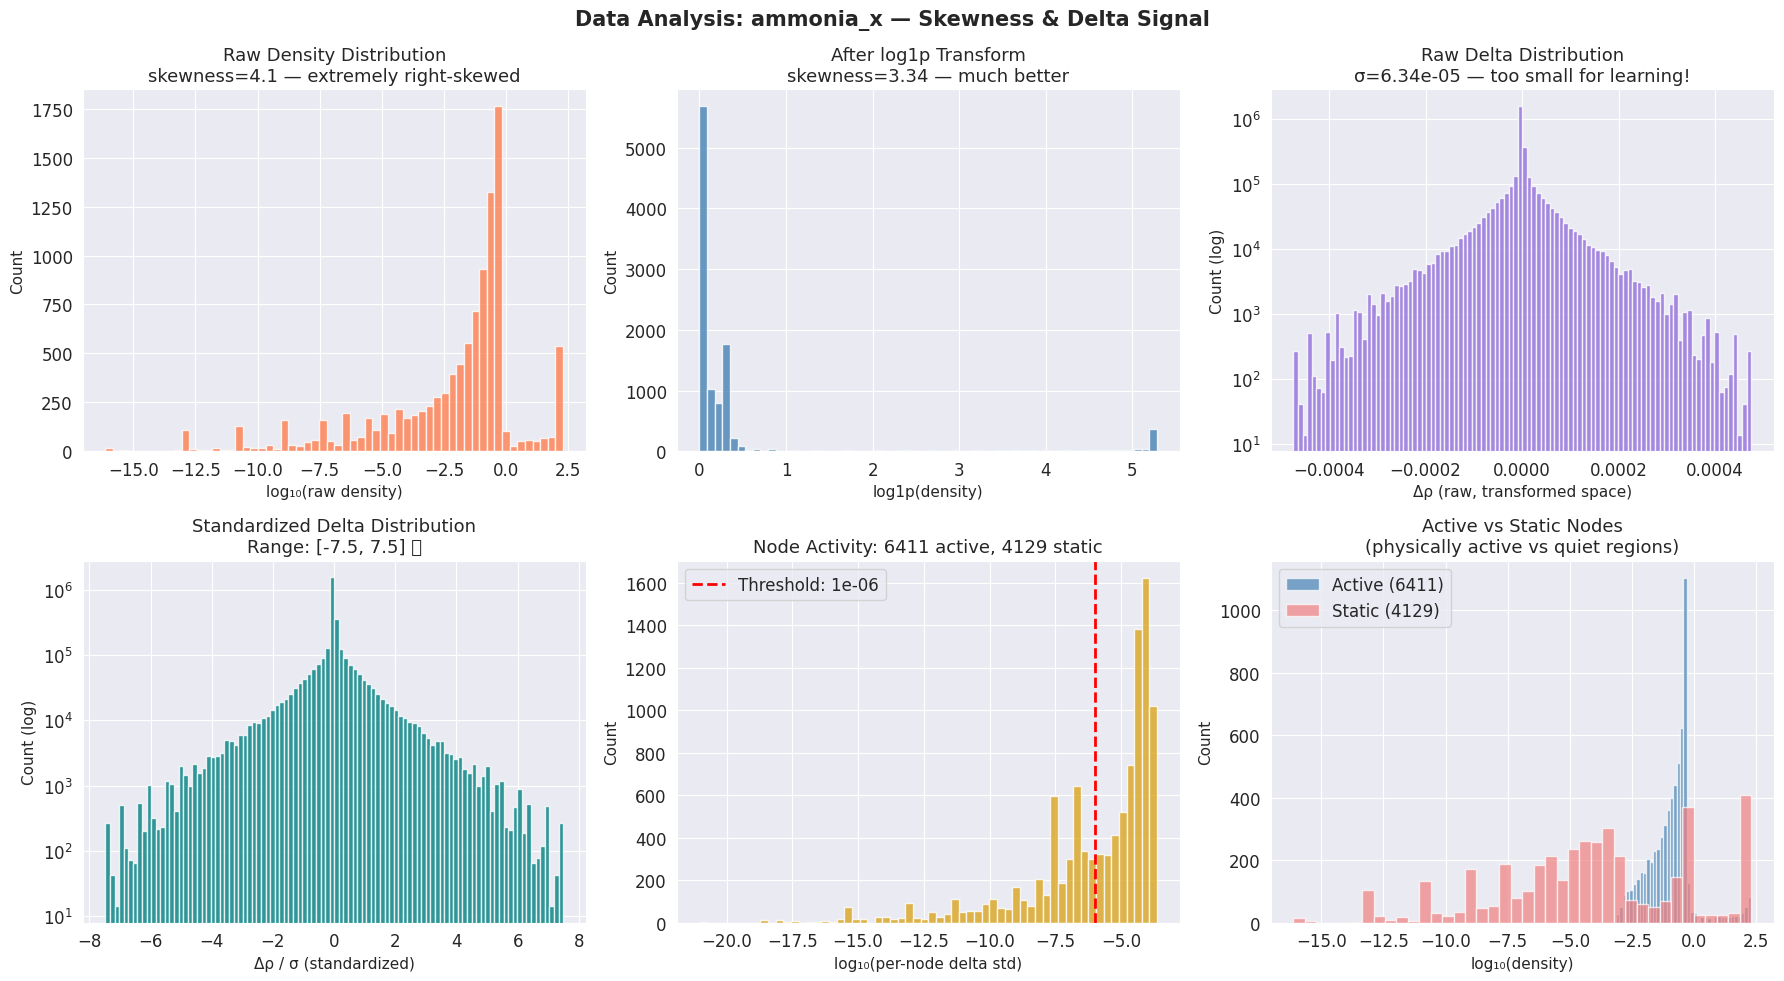

💾 Saved: reports/dataset_insights.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Data Analysis: {DATASET_NAME} — Skewness & Delta Signal', fontsize=15, fontweight='bold')

ax = axes[0, 0]
vals = all_raw[0]
ax.hist(np.log10(np.clip(vals, 1e-20, None)), bins=60, color='coral', edgecolor='white', alpha=0.8)
ax.set_xlabel('log₁₀(raw density)'); ax.set_ylabel('Count')
ax.set_title(f'Raw Density Distribution\nskewness={stats.skew(vals):.1f} — extremely right-skewed')

ax = axes[0, 1]
vals_tf = all_tf[0]
ax.hist(vals_tf, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('log1p(density)'); ax.set_ylabel('Count')
ax.set_title(f'After log1p Transform\nskewness={stats.skew(vals_tf):.2f} — much better')

ax = axes[0, 2]
ax.hist(train_deltas.flatten(), bins=100, color='mediumpurple', edgecolor='white', alpha=0.8, log=True)
ax.set_xlabel('Δρ (raw, transformed space)'); ax.set_ylabel('Count (log)')
ax.set_title(f'Raw Delta Distribution\nσ={DELTA_STD:.2e} — too small for learning!')

ax = axes[1, 0]
ax.hist(scaled_demo.flatten(), bins=100, color='teal', edgecolor='white', alpha=0.8, log=True)
ax.set_xlabel('Δρ / σ (standardized)'); ax.set_ylabel('Count (log)')
ax.set_title(f'Standardized Delta Distribution\nRange: [{scaled_demo.min():.1f}, {scaled_demo.max():.1f}] ✅')

ax = axes[1, 1]
log_std = np.log10(np.clip(per_node_std, 1e-25, None))
ax.hist(log_std, bins=60, color='goldenrod', edgecolor='white', alpha=0.8)
ax.axvline(np.log10(ACTIVE_STD_THRESHOLD), color='red', linestyle='--', lw=2,
           label=f'Threshold: {ACTIVE_STD_THRESHOLD:.0e}')
ax.set_xlabel('log₁₀(per-node delta std)'); ax.set_ylabel('Count')
ax.set_title(f'Node Activity: {N_ACTIVE} active, {N_STATIC} static')
ax.legend()

ax = axes[1, 2]
ax.hist(np.log10(np.clip(all_raw[0, active_mask], 1e-20, None)), bins=40, alpha=0.7,
        color='steelblue', label=f'Active ({N_ACTIVE})', edgecolor='white')
ax.hist(np.log10(np.clip(all_raw[0, ~active_mask], 1e-20, None)), bins=40, alpha=0.7,
        color='lightcoral', label=f'Static ({N_STATIC})', edgecolor='white')
ax.set_xlabel('log₁₀(density)'); ax.set_ylabel('Count')
ax.set_title('Active vs Static Nodes\n(physically active vs quiet regions)')
ax.legend()

plt.tight_layout()
plt.savefig(str(REPORTS_DIR / 'dataset_insights.png'), dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: reports/dataset_insights.png")

## 5. Graph Construction

Two complementary edge types:
- **Sequential edges** (k=5): connect grid neighbors by index — captures grid ordering
- **kNN spatial edges** (k=10): connect nearest neighbors in 3D space — captures physical locality

In [ ]:

def build_seq_edges(n, k):
    src, dst = [], []
    for i in range(n):
        for j in range(max(0, i-k), min(n, i+k+1)):
            if i != j: src.append(i); dst.append(j)
    return torch.tensor([src, dst], dtype=torch.long)

def build_knn_edges(coords, k):
    from sklearn.neighbors import NearestNeighbors
    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='ball_tree').fit(coords)
    _, idx = nbrs.kneighbors(coords)
    src, dst = [], []
    for i in range(len(coords)):
        for j in idx[i, 1:]:
            src.extend([i, int(j)]); dst.extend([int(j), i])
    return torch.unique(torch.tensor([src, dst], dtype=torch.long), dim=1)

print(f"🔗 Building graph ({NUM_NODES} nodes)...")
seq_edges = build_seq_edges(NUM_NODES, SEQ_NEIGHBORS)
knn_edges = build_knn_edges(grid_coords, K_NEIGHBORS)
graph_edges = torch.unique(torch.cat([seq_edges, knn_edges], dim=1), dim=1)
print(f"   Seq edges:  {seq_edges.shape[1]}")
print(f"   kNN edges:  {knn_edges.shape[1]}")
print(f"   Combined:   {graph_edges.shape[1]}  (avg degree: {graph_edges.shape[1]/NUM_NODES:.1f})")

🔗 Building graph (10540 nodes)...
   Seq edges:  105370
   kNN edges:  136080
   Combined:   240522  (avg degree: 22.8)


## 6. Dataset — Standardized Delta Prediction

### Core fix: Delta Standardization
The model predicts **standardized deltas**: `z = (Δρ - μ) / σ`  
- μ ≈ 0, σ ≈ 6.4×10⁻⁵ (computed from training data only)  
- Scale factor ≈ 15,680× — puts targets in [-7, 7] range  
- At inference: `Δρ = z_predicted × σ + μ`

### Node Activity Weights
Per-node loss weight = `sqrt(node_delta_std)` for active nodes, 0 for static nodes.  
This makes the model concentrate on nodes that actually change.

In [ ]:

node_weights_np = np.zeros(NUM_NODES, dtype=np.float32)
node_weights_np[active_mask] = np.sqrt(per_node_std[active_mask]).astype(np.float32)
if node_weights_np[active_mask].sum() > 0:
    node_weights_np[active_mask] *= N_ACTIVE / node_weights_np[active_mask].sum()

NODE_WEIGHTS_TENSOR = torch.tensor(node_weights_np, dtype=torch.float32)

class DensityDataset(Dataset):
    """
    Sliding window: LOOKBACK timesteps → standardized delta for t+LOOKAHEAD.
    
    Key points:
    - all_tf is float64 — ensures delta is computed precisely before casting
    - Target = (Δρ - μ) / σ  i.e. z-scored (model works in [-7,7] not [-4e-4,4e-4])
    - Stores raw delta & absolute target for evaluation only (not for loss)
    """
    def __init__(self, density_tf, edge_index, node_weights,
                 lookback, lookahead, delta_mean, delta_std):
        super().__init__()
        self.tf    = density_tf      # (T, N) float64
        self.edges = edge_index
        self.w     = node_weights    # (N,) float32
        self.lb    = lookback
        self.la    = lookahead
        self.mu    = delta_mean      # float64
        self.sigma = delta_std       # float64
        self.n     = len(density_tf) - lookback - lookahead + 1

    def len(self): return self.n

    def get(self, idx):
        x = torch.tensor(self.tf[idx : idx+self.lb].T, dtype=torch.float32)

        last_i   = idx + self.lb - 1
        target_i = idx + self.lb + self.la - 1

        raw_delta = (self.tf[target_i] - self.tf[last_i])          # (N,) float64
        std_delta = ((raw_delta - self.mu) / self.sigma)            # (N,) float64  scaled
        std_delta_f32 = std_delta.astype(np.float32)               # → float32

        return Data(
            x            = x,
            edge_index   = self.edges,
            y            = torch.tensor(std_delta_f32),             # TRAINING TARGET (scaled)
            node_weights = self.w,
            last_input   = torch.tensor(self.tf[last_i], dtype=torch.float32),
            abs_target   = torch.tensor(self.tf[target_i], dtype=torch.float32),
            raw_delta    = torch.tensor(raw_delta.astype(np.float32)),  # for eval
            ts_idx       = torch.tensor(idx),
        )

dataset = DensityDataset(
    all_tf, graph_edges, NODE_WEIGHTS_TENSOR,
    LOOKBACK, LOOKAHEAD, DELTA_MEAN, DELTA_STD
)

sample = dataset[0]
print(f"📦 Dataset: {len(dataset)} samples")
print(f"   x shape :      {sample.x.shape}   (nodes × lookback)")
print(f"   y (scaled Δ):  [{sample.y.min():.2f}, {sample.y.max():.2f}]  ✅ learnable range")
print(f"   Expected σ=1:  {sample.y.std():.3f}")

📦 Dataset: 396 samples
   x shape :      torch.Size([10540, 5])   (nodes × lookback)
   y (scaled Δ):  [-4.12, 4.12]  ✅ learnable range
   Expected σ=1:  0.880


In [ ]:
n   = len(dataset)
n_tr= int(TRAIN_RATIO * n)
n_va= int(VAL_RATIO   * n)
n_te= n - n_tr - n_va

train_ds = [dataset[i] for i in range(n_tr)]
val_ds   = [dataset[i] for i in range(n_tr, n_tr+n_va)]
test_ds  = [dataset[i] for i in range(n_tr+n_va, n)]

nw  = min(4, os.cpu_count() or 1)
pin = torch.cuda.is_available()
kw  = dict(num_workers=nw, pin_memory=pin, persistent_workers=nw>0)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  **kw)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, **kw)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, **kw)

print(f"📊 Split  (chronological — NO shuffle):")
print(f"   Train {TRAIN_RATIO:.0%}: {n_tr} samples")
print(f"   Val   {VAL_RATIO:.0%}:  {n_va} samples")
print(f"   Test  {TEST_RATIO:.0%}:  {n_te} samples")

📊 Split  (chronological — NO shuffle):
   Train 80%: 316 samples
   Val   10%:  39 samples
   Test  10%:  41 samples


## 7. Model: Temporal Graph Attention Network

**Architecture flow:**
```
Input (N, 5) → InputProjection(5→128) → 4× [GATConv + LayerNorm + GELU + Residual] → OutputHead(128→1)
```
Model outputs **standardized delta** per node. Post-hoc we un-scale to get the real density change.

In [ ]:

class TemporalGAT(nn.Module):
    """
    4-layer GAT predicting standardized deltas.
    Input dim = LOOKBACK (temporal history at each node).
    Output = 1 scalar per node  (z-scored Δρ).
    """
    def __init__(self, input_dim, hidden=128, n_layers=4, heads=4, dropout=0.10):
        super().__init__()
        self.drop = dropout

        self.proj = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.gats  = nn.ModuleList()
        self.norms = nn.ModuleList()
        for i in range(n_layers):
            last   = (i == n_layers - 1)
            out_ch = hidden // heads if not last else hidden
            self.gats.append(GATConv(hidden, out_ch,
                                     heads=heads if not last else 1,
                                     concat=not last,
                                     dropout=dropout, add_self_loops=True))
            self.norms.append(nn.LayerNorm(hidden))

        self.head = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden // 2, hidden // 4), nn.GELU(),
            nn.Linear(hidden // 4, 1),
        )

    def forward(self, data, return_attn=False):
        x, ei = data.x, data.edge_index
        x = self.proj(x)
        last_a = None
        for gat, norm in zip(self.gats, self.norms):
            xr = x
            if return_attn:
                x, last_a = gat(x, ei, return_attention_weights=True)
            else:
                x = gat(x, ei)
            x = norm(x)
            x = F.gelu(x)
            x = F.dropout(x, p=self.drop, training=self.training)
            if x.shape == xr.shape:
                x = x + xr
        out = self.head(x).squeeze(-1)
        return (out, last_a) if return_attn else out

model = TemporalGAT(LOOKBACK, HIDDEN_DIM, NUM_LAYERS, NUM_HEADS, DROPOUT).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"🏗️  TemporalGAT: {n_params:,} parameters")
print(f"   Input: ({NUM_NODES}, {LOOKBACK})  →  Output: ({NUM_NODES},) standardized delta")

🏗️  TemporalGAT: 79,489 parameters
   Input: (10540, 5)  →  Output: (10540,) standardized delta


## 8. Training — Variance-Weighted Loss

**Standard MSE** treats all 10,540 nodes equally — 39% of them are near-zero static nodes that should NOT influence training.

**Weighted MSE** used here:
```python
loss = sum( weight[i] × (pred[i] - true[i])² )  /  sum(weight[i] for active i)
```
where `weight[i] = sqrt(node_temporal_std[i])` for active nodes, 0 for static.

This focuses ALL gradient signal on nodes that actually exhibit electron density dynamics.

**Scheduler**: Cosine Annealing with Warm Restarts (`T₀=20`) — avoids LR plateaus, helps escape local minima.

In [ ]:

class WeightedMSE(nn.Module):
    """MSE weighted by per-node temporal activity. Static nodes masked out."""
    def forward(self, pred, target, weights):
        # pred, target, weights: (N,) per graph-node
        sq = (pred - target) ** 2    # element-wise
        active = (weights > 0).float()
        n_active = active.sum().clamp(min=1.0)
        return (sq * weights).sum() / n_active

criterion = WeightedMSE()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=20, T_mult=2, eta_min=1e-6)

use_amp = torch.cuda.is_available()
amp_scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

def train_epoch(model, loader, opt, criterion, device, scaler, amp):
    model.train()
    total, n = 0.0, 0
    for batch in loader:
        batch = batch.to(device, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=amp):
            pred = model(batch)
            loss = criterion(pred, batch.y, batch.node_weights)
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(opt); scaler.update()
        total += loss.item() * batch.num_graphs
        n += batch.num_graphs
    return total / n

@torch.no_grad()
def eval_epoch(model, loader, criterion, device, amp):
    model.eval()
    total, n = 0.0, 0
    for batch in loader:
        batch = batch.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=amp):
            pred = model(batch)
            loss = criterion(pred, batch.y, batch.node_weights)
        total += loss.item() * batch.num_graphs
        n += batch.num_graphs
    return total / n

best_path = str(MODEL_DIR / f"best_gat_{DATASET_NAME}_lb{LOOKBACK}.pt")
train_l, val_l = [], []
best_val = float('inf')
no_imp   = 0

print("🚀 Training TemporalGAT (standardized deltas + variance-weighted loss)")
print(f"   Scheduler: CosineAnnealingWarmRestarts (T₀=20, T_mult=2)")
print(f"   Active nodes in loss: {N_ACTIVE} / {NUM_NODES}")
print("-" * 80)
t0 = time.time()

for ep in range(1, EPOCHS + 1):
    te = time.time()
    tl = train_epoch(model, train_loader, optimizer, criterion, device, amp_scaler, use_amp)
    vl = eval_epoch(model, val_loader, criterion, device, use_amp)
    scheduler.step(ep)
    train_l.append(tl); val_l.append(vl)

    improved = vl < best_val
    if improved:
        best_val = vl; no_imp = 0
        torch.save(model.state_dict(), best_path)
    else:
        no_imp += 1

    lr_now = optimizer.param_groups[0]['lr']
    if ep % 5 == 0 or ep <= 3 or improved:
        mark = "  ⬇ BEST" if improved else ""
        print(f"  Ep {ep:3d}/{EPOCHS} | Train: {tl:.5f} | Val: {vl:.5f} | "
              f"LR: {lr_now:.1e} | {time.time()-te:.1f}s{mark}")

    if no_imp >= PATIENCE:
        print(f"\n⛔ Early stopping at epoch {ep} (no improvement for {PATIENCE} epochs)")
        break

tot = time.time() - t0
print(f"\n✅ Done: {len(train_l)} epochs, {tot:.0f}s ({tot/60:.1f} min)")
print(f"   Best val loss: {best_val:.6f}")
print(f"   Model saved:  {best_path}")

🚀 Training TemporalGAT (standardized deltas + variance-weighted loss)
   Scheduler: CosineAnnealingWarmRestarts (T₀=20, T_mult=2)
   Active nodes in loss: 6411 / 10540
--------------------------------------------------------------------------------
  Ep   1/100 | Train: 2.66400 | Val: 2.82852 | LR: 3.0e-04 | 6.2s  ⬇ BEST
  Ep   2/100 | Train: 2.66153 | Val: 2.82851 | LR: 2.9e-04 | 5.7s  ⬇ BEST
  Ep   3/100 | Train: 2.66145 | Val: 2.82851 | LR: 2.8e-04 | 5.8s
  Ep   5/100 | Train: 2.66140 | Val: 2.82850 | LR: 2.6e-04 | 5.9s  ⬇ BEST
  Ep  10/100 | Train: 2.66136 | Val: 2.82852 | LR: 1.5e-04 | 7.3s
  Ep  11/100 | Train: 2.66134 | Val: 2.82850 | LR: 1.3e-04 | 5.9s  ⬇ BEST
  Ep  15/100 | Train: 2.66129 | Val: 2.82850 | LR: 4.5e-05 | 7.4s  ⬇ BEST
  Ep  16/100 | Train: 2.66132 | Val: 2.82850 | LR: 3.0e-05 | 6.0s  ⬇ BEST
  Ep  20/100 | Train: 2.66130 | Val: 2.82850 | LR: 3.0e-04 | 6.0s
  Ep  22/100 | Train: 2.66136 | Val: 2.82850 | LR: 3.0e-04 | 6.0s  ⬇ BEST
  Ep  25/100 | Train: 2.66134 | Val

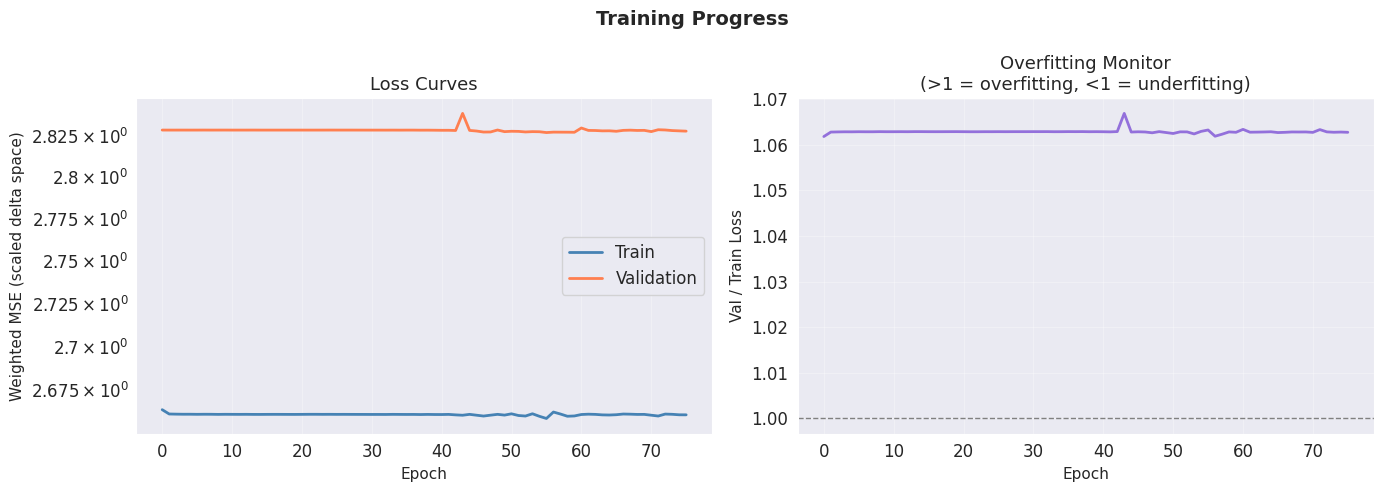

💾 Saved: reports/training_curves.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Progress', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(train_l, label='Train',      color='steelblue', lw=2)
ax.plot(val_l,   label='Validation', color='coral',     lw=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Weighted MSE (scaled delta space)')
ax.set_title('Loss Curves'); ax.legend(); ax.set_yscale('log'); ax.grid(alpha=0.3)

ax = axes[1]
ratio = np.array(val_l) / (np.array(train_l) + 1e-20)
ax.plot(ratio, color='mediumpurple', lw=2)
ax.axhline(1.0, color='gray', ls='--', lw=1)
ax.set_xlabel('Epoch'); ax.set_ylabel('Val / Train Loss')
ax.set_title('Overfitting Monitor\n(>1 = overfitting, <1 = underfitting)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(REPORTS_DIR / 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: reports/training_curves.png")

## 9. Evaluation & Metrics (Model-Only)

**Metric Strategy:**
1. Load the **best checkpoint** (not final epoch) 
2. Collect predictions -> un-scale -> reconstruct absolute density
3. Report metrics on **all nodes** AND **active nodes only**

This notebook intentionally reports **model-only metrics** with no reference-model comparison.

In [ ]:

model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()

buf = {'pred_z':[], 'true_z':[], 'raw_delta':[], 'last_in':[], 'abs_tgt':[], 'w':[]}
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=use_amp):
            pred = model(batch)
        buf['pred_z'].append(pred.cpu().numpy())
        buf['true_z'].append(batch.y.cpu().numpy())
        buf['raw_delta'].append(batch.raw_delta.cpu().numpy())
        buf['last_in'].append(batch.last_input.cpu().numpy())
        buf['abs_tgt'].append(batch.abs_target.cpu().numpy())
        buf['w'].append(batch.node_weights.cpu().numpy())

pred_z    = np.concatenate(buf['pred_z'])    # scaled predictions
true_z    = np.concatenate(buf['true_z'])    # scaled ground truth
raw_true  = np.concatenate(buf['raw_delta']) # actual Δρ (float32 approx)
last_in   = np.concatenate(buf['last_in'])   # log1p(ρ) at last known step
abs_tgt   = np.concatenate(buf['abs_tgt'])   # log1p(ρ) at target step
w_all     = np.concatenate(buf['w'])         # per-node weights (tiled)

pred_delta = pred_z.astype(np.float64) * DELTA_STD + DELTA_MEAN  # float64

pred_logtf = last_in.astype(np.float64) + pred_delta    # log1p pred
true_logtf = abs_tgt.astype(np.float64)                 # log1p true

pred_orig  = np.expm1(pred_logtf)
true_orig  = np.expm1(true_logtf)

active_test = w_all > 0

print(f"📊 Test predictions: {len(pred_z):,} total  |  active: {active_test.sum():,} ({active_test.mean()*100:.1f}%)")
print(f"   pred_z range:   [{pred_z.min():.2f}, {pred_z.max():.2f}]")
print(f"   pred delta range: [{pred_delta.min():.4e}, {pred_delta.max():.4e}]")
print(f"   true delta range: [{raw_true.min():.4e}, {raw_true.max():.4e}]")

📊 Test predictions: 432,140 total  |  active: 262,851 (60.8%)
   pred_z range:   [-0.02, 0.01]
   pred delta range: [-1.0273e-06, 4.0984e-07]
   true delta range: [-4.4883e-04, 4.4867e-04]


In [ ]:

def metrics(pred, true, mask=None):
    if mask is not None:
        pred, true = pred[mask], true[mask]
    res = pred - true
    mse  = float(np.mean(res**2))
    rmse = float(np.sqrt(mse))
    mae  = float(np.mean(np.abs(res)))
    # NRMSE — range-relative
    r    = float(np.ptp(true))
    nrmse= rmse / r * 100 if r > 0 else 0.0
    # R²
    ss_r = np.sum(res**2); ss_t = np.sum((true - true.mean())**2)
    r2   = float(1 - ss_r/ss_t) if ss_t > 0 else 0.0
    # MAPE (skip near-zero)
    nz   = np.abs(true) > 1e-10
    mape = float(np.mean(np.abs(res[nz]/true[nz]))*100) if nz.sum() else float('nan')
    # Cosine sim
    n_p  = np.linalg.norm(pred.flatten()); n_t = np.linalg.norm(true.flatten())
    cos  = float(np.dot(pred.flatten(), true.flatten()) / (n_p * n_t + 1e-20))
    # Pearson r
    pr   = float(stats.pearsonr(pred.flatten(), true.flatten())[0]) if len(pred) > 1 else 0.0
    # Within-X% (on non-zero nodes)
    within = {}
    for t in [0.1, 0.5, 1.0, 5.0]:
        within[t] = float((np.abs(res[nz]/true[nz])*100 < t).mean()*100) if nz.sum() else 0.0
    return dict(MSE=mse, RMSE=rmse, MAE=mae, NRMSE_pct=nrmse,
                R2=r2, MAPE_pct=mape, Cosine_Sim=cos, Pearson_r=pr,
                **{f'Within_{k}pct':v for k,v in within.items()})

m = {
    'scaled_model':       metrics(pred_z, true_z),
    'delta_all_model':    metrics(pred_delta, raw_true.astype(np.float64)),
    'delta_act_model':    metrics(pred_delta, raw_true.astype(np.float64), mask=active_test),
    'abs_all_model':      metrics(pred_orig, true_orig),
    'abs_act_model':      metrics(pred_orig, true_orig, mask=active_test),
}

W = 90
print("=" * W)
print("📊 FINAL TEST METRICS (MODEL-ONLY)")
print("=" * W)

sections = [
    ("A  Scaled-delta space (model output)", 'scaled_model'),
    ("B  Raw delta — ALL nodes",             'delta_all_model'),
    ("C  Raw delta — ACTIVE nodes only ★",   'delta_act_model'),
    ("D  Absolute density — ALL nodes",      'abs_all_model'),
    ("E  Absolute density — ACTIVE nodes ★", 'abs_act_model'),
]
for title, mk in sections:
    print(f"\n{'─'*W}")
    print(f"  {title}")
    print(f"  {'Metric':<22} {'Model':>14}")
    print(f"  {'─'*22} {'─'*14}")
    for key in ['R2','MAE','RMSE','NRMSE_pct','MAPE_pct','Cosine_Sim']:
        if key not in m[mk]:
            continue
        mv = m[mk][key]
        print(f"  {key:<22} {mv:>14.6f}")
    for t in [0.1,0.3,0.5,1.0,5.0]:
        k = f'Within_{t}pct'
        if k in m[mk]:
            mv = m[mk][k]
            print(f"  {k:<22} {mv:>13.2f}%")

print(f"\n{'─'*W}")
print("  MODEL-ONLY SUMMARY")
print(f"  {'─'*W}")
for title, mk in sections:
    print(f"  {title[:45]:<45} MAE: {m[mk]['MAE']:.6e}   R²: {m[mk]['R2']:+.6f}")

📊 FINAL TEST METRICS (MODEL-ONLY)

──────────────────────────────────────────────────────────────────────────────────────────
  A  Scaled-delta space (model output)
  Metric                          Model
  ────────────────────── ──────────────
  R2                           0.000486
  MAE                          0.501008
  RMSE                         1.035419
  NRMSE_pct                    7.313474
  MAPE_pct                155689.074707
  Cosine_Sim                   0.050255
  Within_0.1pct                   0.00%
  Within_0.5pct                   0.03%
  Within_1.0pct                   0.07%
  Within_5.0pct                   0.31%

──────────────────────────────────────────────────────────────────────────────────────────
  B  Raw delta — ALL nodes
  Metric                          Model
  ────────────────────── ──────────────
  R2                           0.000486
  MAE                          0.000032
  RMSE                         0.000066
  NRMSE_pct                    7.313

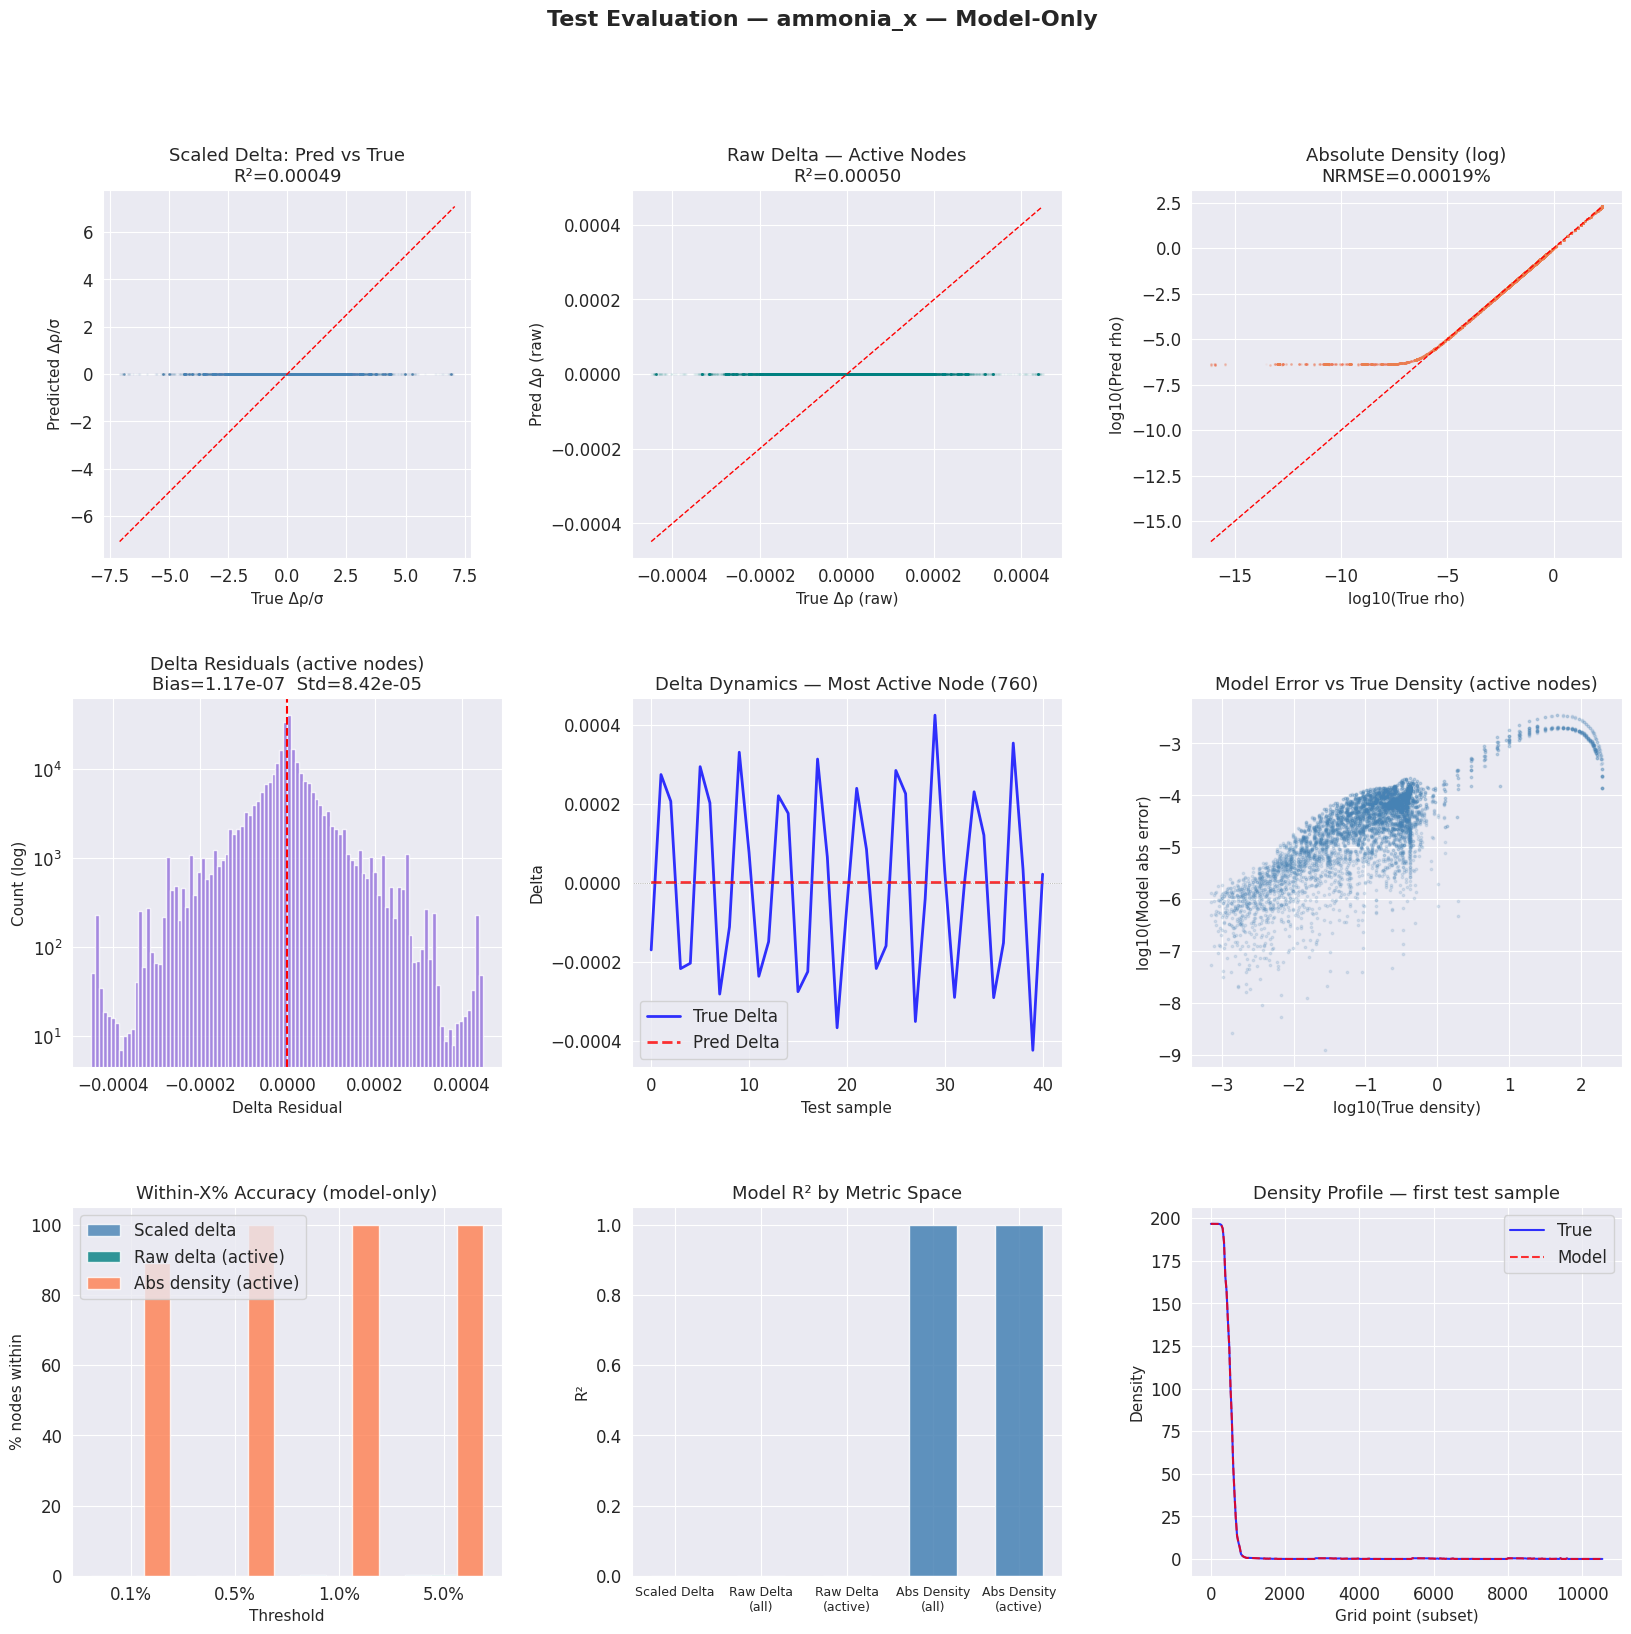

💾 Saved: reports/test_evaluation_no_baseline.png


In [ ]:

fig = plt.figure(figsize=(20, 18))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.38, wspace=0.3)
fig.suptitle(f'Test Evaluation — {DATASET_NAME} — Model-Only', fontsize=16, fontweight='bold')

NP = 50_000
ridx = np.random.choice(len(pred_z), min(NP, len(pred_z)), replace=False)

# 1) Scaled delta: pred vs true
ax = fig.add_subplot(gs[0, 0])
ax.scatter(true_z[ridx], pred_z[ridx], alpha=0.03, s=1, c='steelblue')
lim = max(np.abs(true_z[ridx]).max(), np.abs(pred_z[ridx]).max())
ax.plot([-lim,lim],[-lim,lim],'r--',lw=1); ax.set_aspect('equal')
ax.set_xlabel('True Δρ/σ'); ax.set_ylabel('Predicted Δρ/σ')
ax.set_title(f'Scaled Delta: Pred vs True\nR²={m["scaled_model"]["R2"]:.5f}')

# 2) Raw delta active nodes
ax = fig.add_subplot(gs[0, 1])
ai = np.where(active_test)[0]
sai= ai[np.random.choice(len(ai), min(NP,len(ai)), replace=False)]
ax.scatter(raw_true[sai], pred_delta[sai], alpha=0.04, s=1, c='teal')
lim = max(np.abs(raw_true[sai]).max(), np.abs(pred_delta[sai]).max())
ax.plot([-lim,lim],[-lim,lim],'r--',lw=1)
ax.set_xlabel('True Δρ (raw)'); ax.set_ylabel('Pred Δρ (raw)')
ax.set_title(f'Raw Delta — Active Nodes\nR²={m["delta_act_model"]["R2"]:.5f}')

# 3) Absolute density log scale
ax = fig.add_subplot(gs[0, 2])
ax.scatter(np.log10(np.clip(true_orig[ridx],1e-20,None)),
           np.log10(np.clip(pred_orig[ridx],1e-20,None)),
           alpha=0.02, s=1, c='coral')
mn = min(np.log10(np.clip(true_orig,1e-20,None)).min(), np.log10(np.clip(pred_orig,1e-20,None)).min())
mx = max(np.log10(np.clip(true_orig,1e-20,None)).max(), np.log10(np.clip(pred_orig,1e-20,None)).max())
ax.plot([mn,mx],[mn,mx],'r--',lw=1)
ax.set_xlabel('log10(True rho)'); ax.set_ylabel('log10(Pred rho)')
ax.set_title(f'Absolute Density (log)\nNRMSE={m["abs_all_model"]["NRMSE_pct"]:.5f}%')

# 4) Residual distribution (active nodes)
ax = fig.add_subplot(gs[1, 0])
resid_act = (pred_delta - raw_true.astype(np.float64))[active_test]
ax.hist(resid_act, bins=100, color='mediumpurple', edgecolor='white', alpha=0.8, log=True)
ax.axvline(0, color='red', ls='--')
ax.set_xlabel('Delta Residual'); ax.set_ylabel('Count (log)')
ax.set_title(f'Delta Residuals (active nodes)\nBias={resid_act.mean():.2e}  Std={resid_act.std():.2e}')

# 5) Most active node: delta over time
ax = fig.add_subplot(gs[1, 1])
top_node = np.argsort(per_node_std)[-1]
n_test_s = len(test_ds)
pred_node = pred_delta.reshape(n_test_s, NUM_NODES)[:, top_node]
true_node = raw_true.reshape(n_test_s, NUM_NODES)[:, top_node]
ax.plot(true_node, 'b-', lw=2, alpha=0.8, label='True Delta')
ax.plot(pred_node, 'r--', lw=2, alpha=0.8, label='Pred Delta')
ax.axhline(0, color='gray', ls=':', lw=0.5)
ax.set_xlabel('Test sample'); ax.set_ylabel('Delta')
ax.set_title(f'Delta Dynamics — Most Active Node ({top_node})'); ax.legend()

# 6) Per-node absolute error distribution (active nodes, first test sample)
ax = fig.add_subplot(gs[1, 2])
me1 = np.abs(pred_orig[:NUM_NODES] - true_orig[:NUM_NODES])
act1= node_weights_np > 0
ax.scatter(np.log10(np.clip(true_orig[:NUM_NODES][act1],1e-20,None)),
           np.log10(np.clip(me1[act1],1e-25,None)),
           alpha=0.15, s=3, c='steelblue')
ax.set_xlabel('log10(True density)'); ax.set_ylabel('log10(Model abs error)')
ax.set_title('Model Error vs True Density (active nodes)')

# 7) Within-X% (model-only, key spaces)
ax = fig.add_subplot(gs[2, 0])
thresholds = [0.1, 0.5, 1.0, 5.0]
s = [m['scaled_model'].get(f'Within_{t}pct', 0) for t in thresholds]
d = [m['delta_act_model'].get(f'Within_{t}pct', 0) for t in thresholds]
a = [m['abs_act_model'].get(f'Within_{t}pct', 0) for t in thresholds]
xx = np.arange(len(thresholds)); wd = 0.25
ax.bar(xx-wd, s, wd, label='Scaled delta', color='steelblue', alpha=0.8)
ax.bar(xx,    d, wd, label='Raw delta (active)', color='teal', alpha=0.8)
ax.bar(xx+wd, a, wd, label='Abs density (active)', color='coral', alpha=0.8)
ax.set_xticks(xx); ax.set_xticklabels([f'{t}%' for t in thresholds])
ax.set_xlabel('Threshold'); ax.set_ylabel('% nodes within')
ax.set_title('Within-X% Accuracy (model-only)'); ax.legend()

# 8) R² across model metric spaces
ax = fig.add_subplot(gs[2, 1])
cats = ['Scaled Delta', 'Raw Delta\n(all)', 'Raw Delta\n(active)', 'Abs Density\n(all)', 'Abs Density\n(active)']
mr   = [m['scaled_model']['R2'], m['delta_all_model']['R2'],
        m['delta_act_model']['R2'], m['abs_all_model']['R2'], m['abs_act_model']['R2']]
xx = np.arange(len(cats))
ax.bar(xx, mr, width=0.55, color='steelblue', alpha=0.85)
ax.set_xticks(xx); ax.set_xticklabels(cats, fontsize=9)
ax.set_ylabel('R²'); ax.set_title('Model R² by Metric Space')
ax.axhline(0, color='gray', ls='--', lw=0.5)

# 9) Density profile: true vs model
ax = fig.add_subplot(gs[2, 2])
show_n = 300
si = np.linspace(0, NUM_NODES-1, show_n, dtype=int)
ax.plot(si, true_orig[:NUM_NODES][si], 'b-',  lw=1.5, label='True', alpha=0.8)
ax.plot(si, pred_orig[:NUM_NODES][si], 'r--', lw=1.5, label='Model', alpha=0.8)
ax.set_xlabel('Grid point (subset)'); ax.set_ylabel('Density')
ax.set_title('Density Profile — first test sample'); ax.legend()

plt.savefig(str(REPORTS_DIR / 'test_evaluation_no_baseline.png'), dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: reports/test_evaluation_no_baseline.png")

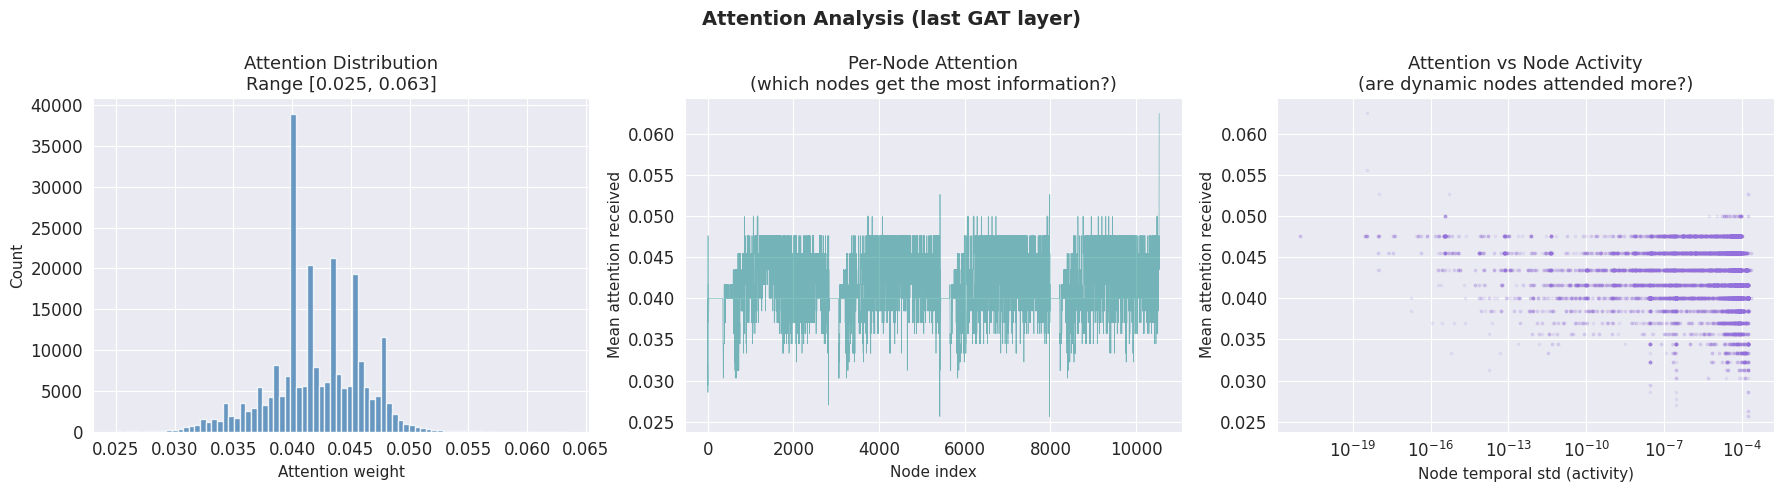

💾 Saved: reports/attention_analysis.png


In [ ]:

model.eval()
sd = test_ds[0].to(device)
with torch.no_grad():
    with torch.cuda.amp.autocast(enabled=use_amp):
        _, (ei_a, aw) = model(sd, return_attn=True)

aw_np = aw.cpu().numpy().flatten()
ei_np = ei_a.cpu().numpy()

# Per-node attention received
attn_recv = np.zeros(NUM_NODES)
attn_cnt  = np.zeros(NUM_NODES)
for e in range(ei_np.shape[1]):
    d = ei_np[1, e]
    if d < NUM_NODES and e < len(aw_np):
        attn_recv[d] += aw_np[e]; attn_cnt[d] += 1
attn_avg = attn_recv / (attn_cnt + 1e-10)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Attention Analysis (last GAT layer)', fontsize=14, fontweight='bold')

ax = axes[0]
ax.hist(aw_np, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('Attention weight'); ax.set_ylabel('Count')
ax.set_title(f'Attention Distribution\nRange [{aw_np.min():.3f}, {aw_np.max():.3f}]')

ax = axes[1]
ax.plot(attn_avg, alpha=0.5, lw=0.5, color='teal')
ax.set_xlabel('Node index'); ax.set_ylabel('Mean attention received')
ax.set_title('Per-Node Attention\n(which nodes get the most information?)')

ax = axes[2]
valid = attn_cnt > 0
ax.scatter(per_node_std[valid], attn_avg[valid], alpha=0.1, s=3, c='mediumpurple')
ax.set_xscale('log'); ax.set_xlabel('Node temporal std (activity)')
ax.set_ylabel('Mean attention received')
ax.set_title('Attention vs Node Activity\n(are dynamic nodes attended more?)')

plt.tight_layout()
plt.savefig(str(REPORTS_DIR / 'attention_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: reports/attention_analysis.png")

## 12. Save Model Weights & Predictions

In [ ]:

final_path = str(MODEL_DIR / f"final_gat_{DATASET_NAME}_lb{LOOKBACK}_work.pt")
torch.save({
    'model_state_dict': model.state_dict(),
    'config': {
        'version': '2_deltaScaled_noBaselineEval', 'dataset': DATASET_NAME,
        'lookback': LOOKBACK, 'lookahead': LOOKAHEAD,
        'hidden_dim': HIDDEN_DIM, 'num_layers': NUM_LAYERS,
        'num_heads': NUM_HEADS, 'dropout': DROPOUT,
        'k_neighbors': K_NEIGHBORS, 'seq_neighbors': SEQ_NEIGHBORS,
        'num_nodes': NUM_NODES, 'train_epochs': len(train_l),
        'best_val_loss': best_val,
        'delta_mean': float(DELTA_MEAN),
        'delta_std':  float(DELTA_STD),
        'active_threshold': ACTIVE_STD_THRESHOLD,
        'evaluation_mode': 'model_only_no_baseline',
    },
    'metrics': m,
    'node_weights': node_weights_np,
}, final_path)
print(f"💾 Final model: {final_path}")
print(f"💾 Best model:  {best_path}")

# ─── Test predictions ───────────────────────────────
pred_file = str(REPORTS_DIR / f"test_predictions_{DATASET_NAME}_work.npz")
np.savez_compressed(pred_file,
    pred_density_original   = pred_orig.astype(np.float32),
    true_density_original   = true_orig.astype(np.float32),
    pred_delta              = pred_delta.astype(np.float32),
    true_delta              = raw_true,
    pred_scaled             = pred_z,
    true_scaled             = true_z,
    active_mask             = active_test,
    node_weights            = node_weights_np,
)
print(f"💾 Predictions: {pred_file}")

# ─── Metrics JSON ────────────────────────────────────
def ser(o):
    if isinstance(o, float) and (np.isnan(o) or np.isinf(o)): return str(o)
    if isinstance(o, (np.floating, float)): return float(o)
    if isinstance(o, dict): return {k: ser(v) for k, v in o.items()}
    return o

mpath = str(REPORTS_DIR / f"metrics_{DATASET_NAME}_work.json")
with open(mpath, 'w') as f:
    json.dump(ser(m), f, indent=2)
print(f"💾 Metrics: {mpath}")

# print("\n" + "═" * 90)
# print("📋 FINAL SUMMARY (test set, model-only)")
# print("═" * 90)
# rows = [
#     ('R² — scaled delta',          m['scaled_model']['R2']),
#     ('R² — raw delta, active ★',   m['delta_act_model']['R2']),
#     ('R² — absolute, active ★',    m['abs_act_model']['R2']),
#     ('MAE — raw delta, active',    m['delta_act_model']['MAE']),
#     ('NRMSE% — raw delta, active', m['delta_act_model']['NRMSE_pct']),
#     ('NRMSE% — absolute, all',     m['abs_all_model']['NRMSE_pct']),
# ]
# print(f"  {'Metric':<38} {'Model':>15}")
# print(f"  {'─'*38} {'─'*15}")
# for label, mv in rows:
#     print(f"  {label:<38} {mv:>15.7f}")

print("\n✅ All outputs saved to reports/ and models")